# Transformer로 한→영 번역기 만들기

첨부 교재 **「Transformer가 나오기까지」·「Transformer로 번역기 만들기 [프로젝트]」**와 기존 프로젝트를 바탕으로 보완한 실습입니다.
기성 번역 모델을 가져오지 않고, 교재처럼 Attention → Encoder/Decoder → Transformer를 직접 구현합니다.

**실행 순서:** 준비 → ★ 설정 → Drive 연결 → 데이터 → 모델 → 학습/재개 → 번역·Attention → 회고.
처음에는 위에서부터 실행하세요. 설정은 **2번 절**, 학습 실행은 **8번 절**, 번역 입력은 **10번 절**에서 바꿉니다.

> 아직 실제 뉴스 데이터로 학습한 결과가 아닙니다. 번역 품질과 루브릭 3번은 학습 후 출력으로 판단해야 합니다.
> 예전 `models/`, `checkpoints/` 파일은 덮어쓰지 않습니다. 새 구조는 `runs/실험이름/`입니다. 예전 체크포인트와 호환되지 않습니다.

[원본 GitHub](https://github.com/yooongZa/AIFFEL_Quest_EPA/blob/main/Transformer_translate_project.ipynb) · [Colab에서 열기](https://colab.research.google.com/github/yooongZa/AIFFEL_Quest_EPA/blob/main/Transformer_translate_project.ipynb)

| 과제·루브릭 | 구현 위치 | 제출 전 확인 |
|---|---|---|
| 중복 쌍 제거·정제·SentencePiece·길이 50 이하 | 4번 | 전처리 통계, 특수 토큰 ID, 텐서 크기 |
| 2층 Transformer·Adam·Noam·PAD 제외 loss | 5~8번 | 정상 학습, train/validation loss |
| 매 epoch 예문 4개 번역 | 7~8번 | 실제 출력이 저장되었는지 |
| 의미가 통하는 번역 + Attention Map | 9~11번 | 누락·추가·부정·수량을 직접 평가 |

검증 데이터로 최적 모델을 고르고 테스트 데이터는 마지막 평가에만 씁니다. 번역 예문 4개는 공식 테스트셋 점수가 아니라 과제의 정성 평가 예문입니다.

## 1. 실행 준비
Colab은 **런타임 → 런타임 유형 변경 → GPU**를 선택합니다. Mac은 Python 환경에 `torch`와 Jupyter 커널이 있어야 합니다.
아래 셀은 없는 보조 패키지만 설치하며, Colab의 기존 PyTorch를 강제로 교체하지 않습니다.

Mac 터미널에서 처음 한 번:
```bash
python -m pip install torch sentencepiece numpy matplotlib pandas tqdm ipykernel
```
VS Code에서 이 패키지를 설치한 Python을 노트북 커널로 선택하세요.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torch") is None:
    raise ImportError("현재 커널에 PyTorch가 없습니다. 이 환경에서 python -m pip install torch 실행 후 커널을 재시작하세요.")

packages = ["sentencepiece", "numpy", "matplotlib", "pandas", "tqdm"]
missing = [name for name in packages if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import os
import re
import math
import json
import random
import hashlib
import shutil
import tarfile
import tempfile
import unicodedata
import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import sentencepiece as spm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm
from IPython.display import display

print("Python:", sys.version.split()[0], "| PyTorch:", torch.__version__)
print("SentencePiece:", spm.__version__)

Python: 3.13.15 | PyTorch: 2.11.0+cu128
SentencePiece: 0.2.2


## 2. ★ 직접 조절하는 설정
처음에는 기본값으로 실행합니다. **학습 횟수만 늘릴 때**는 `RUN_NAME`을 유지하고 `EPOCHS`를 늘립니다.
**데이터·단어장·모델·배치 크기·학습률을 바꾸는 실험**은 `RUN_NAME`을 새 이름으로 바꾸세요. 기존 결과를 보존합니다.
설정을 바꾼 새 실험은 **커널을 재시작하고 위에서부터 실행**하세요. 학습 횟수만 늘리거나 단순 중단 후 재개할 때만 8번 학습 셀을 다시 실행합니다.

`MAX_PAIRS=3000, EPOCHS=1`은 실행 확인용이지 제출용 성능 확인이 아닙니다. 제출 실험은 `MAX_PAIRS=None`부터 시도하세요.
기본 모델 크기는 교재의 512/2048보다 작은 256/1024이며, 2층·8 heads는 유지합니다.

In [2]:
# ★ 자주 바꾸는 항목
RUN_NAME = "baseline_v1"        # 새 실험마다 새 이름: baseline_v2, dropout_03 등
LOCAL_DRIVE_ROOT = ""            # Mac 자동 검색 실패 시 Finder의 '내 드라이브' 전체 경로
DEVICE = "auto"                 # auto / cuda / mps / cpu
RUN_TRAINING = True              # 이미 학습했다면 False로 바꾸고 번역·평가만 실행
RESUME_TRAINING = True           # 같은 실험의 latest.pt가 있으면 이어서 학습
EPOCHS = 10                     # 추가 횟수가 아니라 '총 목표 횟수'
BATCH_SIZE = 32                 # 메모리 부족 시 새 RUN_NAME에서 16으로 낮추기
MAX_PAIRS = None                # None: 전체. 3000: 작은 실행 확인 실험

# ★ 모델·데이터 실험 항목: 변경 시 RUN_NAME도 변경
SRC_VOCAB_SIZE = 20000
TGT_VOCAB_SIZE = 20000
MAX_LEN = 50                    # 영어는 BOS/EOS까지 포함. 과제 제출은 50 유지
N_LAYERS = 2                    # 과제의 2층 조건 유지
D_MODEL = 256                   # 임베딩 차원. 256 → 512 실험 가능
N_HEADS = 8                     # D_MODEL이 N_HEADS로 나누어떨어져야 함
D_FF = 1024                     # FFN 중간 차원. 보통 이 실습에서는 D_MODEL의 4배
DROPOUT = 0.2                   # 0.2 → 0.3 비교 가능
WARMUP_STEPS = 4000             # Noam 학습률이 증가하는 배치 수
LR_SCALE = 1.0                  # Noam 학습률 전체 배율
CLIP_NORM = 1.0                 # 기울기 폭주 방지

# 보통 유지하는 항목
SEED = 42
VAL_RATIO = 0.05
TEST_RATIO = 0.05
CHECKPOINT_EVERY = 100          # 완료 배치 100개마다 + 매 epoch 끝에 저장
ATTENTION_LAYER = -1            # -1: 마지막 층, 0: 첫 층
ATTENTION_HEAD = None           # None: head 평균, 0~7: 특정 head
TEST_EXAMPLES = 5               # 별도 테스트셋에서 출력할 문장 수

assert re.fullmatch(r"[A-Za-z0-9_-]+", RUN_NAME), "실험 이름은 영문·숫자·밑줄·하이픈만 사용하세요."
assert DEVICE in {"auto", "cuda", "mps", "cpu"}
assert TEST_EXAMPLES >= 1
assert N_HEADS > 0 and D_MODEL > 0 and D_FF > 0
assert D_MODEL % N_HEADS == 0 and D_MODEL % 2 == 0
assert 3 <= MAX_LEN <= 50 and N_LAYERS == 2
assert BATCH_SIZE > 0 and EPOCHS >= 0 and CHECKPOINT_EVERY > 0
assert WARMUP_STEPS > 0 and LR_SCALE > 0 and CLIP_NORM > 0
assert 0 <= DROPOUT < 1 and 0 < VAL_RATIO + TEST_RATIO < 1
assert VAL_RATIO > 0 and TEST_RATIO > 0
assert MAX_PAIRS is None or MAX_PAIRS >= 100

## 3. Google Drive와 실행 장치 연결
Colab은 `drive.mount()`로 연결합니다. Mac은 **Google Drive for desktop**으로 동기화한 같은 계정의 '내 드라이브'를 사용합니다.
Mac에 동기화 폴더가 없으면 **로컬 일반 폴더로 몰래 대체하지 않고 중단**합니다. Finder에서 경로를 복사해 `LOCAL_DRIVE_ROOT`에 넣으세요.

저장 구조:
```text
내 드라이브/Aiffel_EPA/transformer/
  data/                     ← 원본 압축파일·한국어·영어
  runs/baseline_v1/
    dataset.pt, data_meta.json, ko_spm.model, en_spm.model ...
    latest.pt               ← 학습 재개용(모델·optimizer·scheduler·진행 상태)
    best.pt                 ← validation loss가 가장 낮은 모델
    results/                ← 학습기록·예문·그림·제출용 요약
```
**Mac과 Colab에서 같은 실험을 동시에 실행하지 마세요.** 장치를 바꿀 때는 Drive 동기화 완료를 확인합니다.
장치 간 가중치 재사용은 가능하도록 작성했지만 CUDA/MPS 계산·난수 차이 때문에 완전히 동일한 결과를 보장하지는 않습니다.

In [3]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    drive_root = Path("/content/drive/MyDrive")
elif LOCAL_DRIVE_ROOT:
    drive_root = Path(LOCAL_DRIVE_ROOT).expanduser()
else:
    roots = []
    for account in (Path.home() / "Library/CloudStorage").glob("GoogleDrive-*"):
        for child in account.iterdir():
            if unicodedata.normalize("NFC", child.name) in {"My Drive", "내 드라이브"} and child.is_dir():
                roots.append(child)
    if len(roots) != 1:
        raise RuntimeError("Drive 경로를 하나로 결정할 수 없습니다. Google Drive 앱을 연결하고 LOCAL_DRIVE_ROOT를 지정하세요.")
    drive_root = roots[0]

if not drive_root.is_dir():
    raise FileNotFoundError(f"Drive 폴더가 없습니다: {drive_root}")
WORK_DIR = drive_root / "Aiffel_EPA/transformer"
DATA_DIR = WORK_DIR / "data"
RUN_DIR = WORK_DIR / "runs" / RUN_NAME
RESULT_DIR = RUN_DIR / "results"
for folder in [DATA_DIR, RUN_DIR, RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

if DEVICE == "auto":
    device = torch.device("cuda" if torch.cuda.is_available() else
                          "mps" if torch.backends.mps.is_available() else "cpu")
else:
    device = torch.device(DEVICE)
if device.type == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA가 없습니다. Colab GPU 런타임을 선택하세요.")
if device.type == "mps" and not torch.backends.mps.is_available():
    raise RuntimeError("MPS를 사용할 수 없습니다. macOS/PyTorch/커널 환경을 확인하세요.")
if device.type == "cpu":
    print("주의: CPU 실행입니다. 전체 학습보다 작은 실행 확인에 적합합니다.")

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)
    elif device.type == "mps":
        torch.mps.manual_seed(seed)

seed_everything(SEED)
print("실행 장치:", device)
print("원본 데이터:", DATA_DIR)
print("실험 저장:", RUN_DIR)

# 한글 Attention 라벨용 폰트. 폰트 설치 실패는 모델 학습 실패와 별개입니다.
font_paths = [Path("/System/Library/Fonts/AppleSDGothicNeo.ttc"),
              Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")]
if IN_COLAB and not any(p.exists() for p in font_paths):
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)
for font_path in font_paths:
    if font_path.exists():
        fm.fontManager.addfont(str(font_path))
        plt.rcParams["font.family"] = fm.FontProperties(fname=str(font_path)).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

Mounted at /content/drive
실행 장치: cuda
원본 데이터: /content/drive/MyDrive/Aiffel_EPA/transformer/data
실험 저장: /content/drive/MyDrive/Aiffel_EPA/transformer/runs/baseline_v1


### 저장 보조 함수

In [4]:
def atomic_save(obj, path):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    try:
        torch.save(obj, temporary)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


def write_json(obj, path):
    temporary = Path(str(path) + ".tmp")
    temporary.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    os.replace(temporary, path)


def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

## 4. 데이터 전처리·SentencePiece·데이터셋
### 4-1. 원본 다운로드: 처음 한 번만
한국어·영어 파일이 이미 있으면 그대로 읽습니다. 압축파일에서는 지정된 두 일반 파일만 읽어 경로 탈출·심볼릭 링크 추출을 피합니다.
데이터는 Drive에 보관하고, 학습할 때는 준비된 CPU 텐서를 메모리에 올린 뒤 배치만 GPU로 옮깁니다.

In [5]:
DATA_URL = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"
RAW_NAMES = ["korean-english-park.train.ko", "korean-english-park.train.en"]


def prepare_parallel_data():
    missing = [name for name in RAW_NAMES if not (DATA_DIR / name).is_file() or (DATA_DIR / name).stat().st_size == 0]
    if not missing:
        print("Drive의 원본 데이터를 재사용합니다.")
        return
    archive_path = DATA_DIR / "korean-english-park.train.tar.gz"
    if not archive_path.exists():
        temporary = Path(str(archive_path) + ".part")
        print("원본 데이터를 다운로드합니다.")
        try:
            with urllib.request.urlopen(DATA_URL, timeout=120) as source, temporary.open("wb") as target:
                shutil.copyfileobj(source, target)
            with tarfile.open(temporary, "r:gz") as archive:
                available = {Path(m.name).name for m in archive.getmembers() if m.isfile()}
                if not set(RAW_NAMES).issubset(available):
                    raise ValueError("압축파일에 필요한 언어 파일이 없습니다.")
            os.replace(temporary, archive_path)
        finally:
            temporary.unlink(missing_ok=True)
    with tarfile.open(archive_path, "r:gz") as archive:
        members = {Path(m.name).name: m for m in archive.getmembers() if m.isfile()}
        for name in missing:
            temporary = DATA_DIR / (name + ".tmp")
            with archive.extractfile(members[name]) as source, temporary.open("wb") as target:
                shutil.copyfileobj(source, target)
            os.replace(temporary, DATA_DIR / name)

prepare_parallel_data()
RAW_HASHES = {name: file_hash(DATA_DIR / name) for name in RAW_NAMES}

원본 데이터를 다운로드합니다.


### 4-2. 문장 쌍 유지·중복 제거·데이터 분리
`set`에는 한국어만 따로, 영어만 따로 넣지 않고 **(한국어, 영어) 쌍**을 넣습니다.
정제 후 새로 같아진 쌍도 제거합니다. 교재 조건대로 숫자·따옴표 등은 제거하며 `?.!,`는 남깁니다.
따라서 숫자로 적힌 수량 정보가 사라질 수 있다는 한계도 회고에 기록하세요.

검증·테스트 문장으로 토크나이저를 학습하지 않습니다. 같은 한국어에 번역이 여러 개면 같은 분할에 배치해 입력 문장 중복 유출을 막습니다.

In [6]:
def preprocess_sentence(sentence):
    sentence = unicodedata.normalize("NFC", sentence).lower()
    sentence = re.sub(r"[^a-z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    return re.sub(r"\s+", " ", sentence).strip()


def clean_and_split():
    korean = (DATA_DIR / RAW_NAMES[0]).read_text(encoding="utf-8").splitlines()
    english = (DATA_DIR / RAW_NAMES[1]).read_text(encoding="utf-8").splitlines()
    if len(korean) != len(english):
        raise ValueError("한국어/영어 줄 수가 다릅니다. 두 파일을 같은 원본에서 복원하세요.")
    raw_seen, clean_seen = set(), set()
    cleaned_corpus = []
    for ko, en in zip(korean, english):
        if (ko, en) in raw_seen:
            continue
        raw_seen.add((ko, en))
        ko, en = preprocess_sentence(ko), preprocess_sentence(en)
        # 빈 문장이나 문장부호만 남은 문장은 학습하지 않습니다.
        if not re.search(r"[a-z가-힣]", ko) or not re.search(r"[a-z가-힣]", en):
            continue
        if (ko, en) not in clean_seen:
            clean_seen.add((ko, en))
            cleaned_corpus.append((ko, en))
    stats = {"raw_pairs": len(korean), "raw_unique_pairs": len(raw_seen),
             "clean_pairs": len(cleaned_corpus)}
    random.Random(SEED).shuffle(cleaned_corpus)
    if MAX_PAIRS is not None:
        cleaned_corpus = cleaned_corpus[:MAX_PAIRS]
    sources = list(dict.fromkeys(ko for ko, en in cleaned_corpus))
    random.Random(SEED).shuffle(sources)
    n_val = max(1, int(len(sources) * VAL_RATIO))
    n_test = max(1, int(len(sources) * TEST_RATIO))
    if len(sources) <= n_val + n_test:
        raise ValueError("분리할 데이터가 부족합니다.")
    val_sources = set(sources[:n_val])
    test_sources = set(sources[n_val:n_val + n_test])
    splits = {"train": [], "val": [], "test": []}
    for pair in cleaned_corpus:
        name = "val" if pair[0] in val_sources else "test" if pair[0] in test_sources else "train"
        splits[name].append(pair)
    stats["selected_pairs"] = len(cleaned_corpus)
    return splits, stats

print(preprocess_sentence("  Obama, 대통령! 123  "))

obama , 대통령 !


### 4-3. 토크나이저와 텐서 준비·재사용
기본 단어장 크기 요청값은 언어별 20,000입니다. 작은 말뭉치에서는 실제 단어 수가 요청값보다 작을 수 있어 실제 크기로 모델을 생성합니다.
`PAD=0, BOS=1, EOS=2, UNK=3`을 검사합니다. 영어에 BOS/EOS를 붙인 뒤 양쪽 길이가 모두 50 이하인 쌍만 사용합니다.

처음 실행하면 토크나이저·텐서·설정 기록을 Drive에 저장합니다. 같은 실험을 다시 열면 재학습 없이 불러옵니다.
원본·전처리·단어장 설정이 달라졌으면 새 `RUN_NAME`을 요구합니다.

In [7]:
DATA_CONFIG = {"version": 2, "raw_hashes": RAW_HASHES, "seed": SEED,
               "max_pairs": MAX_PAIRS, "max_len": MAX_LEN,
               "src_vocab": SRC_VOCAB_SIZE, "tgt_vocab": TGT_VOCAB_SIZE,
               "val_ratio": VAL_RATIO, "test_ratio": TEST_RATIO,
               "sentencepiece_version": spm.__version__}


def generate_tokenizer(corpus, vocab_size=20000, lang="ko"):
    # 임시 로컬 폴더에서 학습한 완성 파일만 Drive로 복사합니다.
    with tempfile.TemporaryDirectory() as temporary:
        prefix = Path(temporary) / lang
        corpus_path = Path(temporary) / "corpus.txt"
        corpus_path.write_text("\n".join(corpus) + "\n", encoding="utf-8")
        spm.SentencePieceTrainer.train(
            input=str(corpus_path), model_prefix=str(prefix), vocab_size=vocab_size,
            model_type="unigram", character_coverage=1.0,
            pad_id=0, bos_id=1, eos_id=2, unk_id=3,
            hard_vocab_limit=False, shuffle_input_sentence=False, num_threads=1,
            minloglevel=1)
        for suffix in [".model", ".vocab"]:
            target = RUN_DIR / f"{lang}_spm{suffix}"
            staged = Path(str(target) + ".tmp")
            shutil.copyfile(str(prefix) + suffix, staged)
            os.replace(staged, target)
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(str(RUN_DIR / f"{lang}_spm.model"))
    return tokenizer


def encode_pairs(pairs, ko_tokenizer, en_tokenizer):
    src_corpus, tgt_corpus, kept_pairs = [], [], []
    for ko, en in pairs:
        src_ids = ko_tokenizer.encode(ko, out_type=int)
        tgt_ids = en_tokenizer.encode(en, out_type=int, add_bos=True, add_eos=True)
        if 1 <= len(src_ids) <= MAX_LEN and 3 <= len(tgt_ids) <= MAX_LEN:
            src_corpus.append(torch.tensor(src_ids, dtype=torch.long))
            tgt_corpus.append(torch.tensor(tgt_ids, dtype=torch.long))
            kept_pairs.append((ko, en))
    if not kept_pairs:
        raise ValueError("길이 제한을 통과한 문장이 없습니다. 데이터 크기·단어장 설정을 확인하세요.")
    return {"src": pad_sequence(src_corpus, batch_first=True, padding_value=0),
            "tgt": pad_sequence(tgt_corpus, batch_first=True, padding_value=0),
            "pairs": kept_pairs}


def prepare_dataset():
    meta_path = RUN_DIR / "data_meta.json"
    dataset_path = RUN_DIR / "dataset.pt"
    if meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
        if meta["config"] != DATA_CONFIG:
            raise ValueError("데이터 설정이 이전 실행과 다릅니다. RUN_NAME을 새 이름으로 바꾸세요.")
        for name, expected_hash in meta["hashes"].items():
            if not (RUN_DIR / name).exists() or file_hash(RUN_DIR / name) != expected_hash:
                raise ValueError(f"저장 파일이 없거나 변경되었습니다: {name}. Drive 동기화 상태를 확인하세요.")
        ko_tokenizer = spm.SentencePieceProcessor(model_file=str(RUN_DIR / "ko_spm.model"))
        en_tokenizer = spm.SentencePieceProcessor(model_file=str(RUN_DIR / "en_spm.model"))
        dataset = torch.load(dataset_path, map_location="cpu", weights_only=True)
        print("Drive의 토크나이저와 데이터셋을 재사용합니다.")
        return dataset, ko_tokenizer, en_tokenizer, meta
    if (RUN_DIR / "latest.pt").exists() or (RUN_DIR / "best.pt").exists():
        raise RuntimeError("체크포인트는 있는데 데이터 기록이 없습니다. 재생성하지 말고 Drive 동기화를 확인하세요.")
    splits, stats = clean_and_split()
    kor_corpus = [ko for ko, en in splits["train"]]
    eng_corpus = [en for ko, en in splits["train"]]
    ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
    en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
    dataset = {}
    for name, pairs in splits.items():
        dataset[name] = encode_pairs(pairs, ko_tokenizer, en_tokenizer)
        stats[name + "_before_length"] = len(pairs)
        stats[name + "_pairs"] = len(dataset[name]["pairs"])
    atomic_save(dataset, dataset_path)
    hashes = {name: file_hash(RUN_DIR / name) for name in ["dataset.pt", "ko_spm.model", "en_spm.model"]}
    meta = {"config": DATA_CONFIG, "stats": stats, "hashes": hashes}
    write_json(meta, meta_path)  # 마지막에 완료 기록을 씁니다.
    return dataset, ko_tokenizer, en_tokenizer, meta

dataset, ko_tokenizer, en_tokenizer, data_meta = prepare_dataset()
PAD, BOS, EOS, UNK = 0, 1, 2, 3
for tokenizer in [ko_tokenizer, en_tokenizer]:
    assert [tokenizer.pad_id(), tokenizer.bos_id(), tokenizer.eos_id(), tokenizer.unk_id()] == [PAD, BOS, EOS, UNK]
enc_train, dec_train = dataset["train"]["src"], dataset["train"]["tgt"]
display(pd.DataFrame([data_meta["stats"]]).T.rename(columns={0: "문장 쌍 수"}))
print("실제 단어장 크기:", ko_tokenizer.vocab_size(), en_tokenizer.vocab_size())
print("enc_train / dec_train:", enc_train.shape, dec_train.shape)
print("한국어 조각:", ko_tokenizer.encode(dataset["train"]["pairs"][0][0], out_type=str))
print("영어 ID(BOS=1, EOS=2):", dec_train[0].tolist())

# 학습·검증·테스트에 같은 한국어 문장이 들어가지 않았는지 검사
source_sets = {name: {ko for ko, en in part["pairs"]} for name, part in dataset.items()}
assert not source_sets["train"] & source_sets["val"]
assert not source_sets["train"] & source_sets["test"]
assert not source_sets["val"] & source_sets["test"]
for part in dataset.values():
    assert part["src"].shape[1] <= MAX_LEN and part["tgt"].shape[1] <= MAX_LEN
    assert torch.all(part["tgt"][:, 0] == BOS)
    assert torch.all((part["tgt"] == EOS).sum(dim=1) == 1)
print("데이터·특수 토큰·분리 검사 통과")

,문장 쌍 수
raw_pairs,94123
raw_unique_pairs,78968
clean_pairs,78802
selected_pairs,78802
train_before_length,70800
train_pairs,67722
val_before_length,4069
val_pairs,3889
test_before_length,3933
test_pairs,3757


실제 단어장 크기: 20000 20000
enc_train / dec_train: torch.Size([67722, 50]) torch.Size([67722, 50])
한국어 조각: ['▁버락', '▁오바마', '▁대통령은', '▁관타나모', '만', '의', '▁해군', '기', '지', '▁수용소', '를', '▁년', '▁안에', '▁폐쇄', '한다는', '▁대통령', '령', '에', '▁서명', '을', '▁할', '▁것으로', '▁예상되고', '▁있습니다', '▁.']
영어 ID(BOS=1, EOS=2): [1, 57, 431, 113, 17, 218, 7, 938, 30, 840, 617, 315, 6, 2601, 4, 104, 708, 22, 4540, 1784, 548, 9, 49, 5, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
데이터·특수 토큰·분리 검사 통과


## 5. 교재 방식으로 Transformer 직접 구현
`__init__`은 사용할 층을 만들고, `forward`는 입력이 지나가는 순서를 정합니다.
모든 실수 연산은 기본 `float32`, 마스크는 `bool`을 사용합니다. 아래 모델 코드는 보통 수정하지 않아도 됩니다.

### 5-1. Padding mask·Causal mask
`True`는 보지 못하게 가릴 위치입니다. 소스 PAD는 Encoder와 Cross-Attention 양쪽에서 가립니다.
Decoder는 미래 토큰과 영어 PAD를 함께 가립니다.

In [8]:
def generate_padding_mask(seq):
    return (seq == PAD)[:, None, None, :]  # [batch, 1, 1, key_length]


def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    # 마스크를 입력과 같은 장치에서 만들어 CPU/CUDA/MPS 혼용을 피합니다.
    future_mask = torch.triu(torch.ones(tgt.size(1), tgt.size(1),
                                       dtype=torch.bool, device=tgt.device), diagonal=1)
    dec_mask = generate_padding_mask(tgt) | future_mask
    return enc_mask, enc_mask, dec_mask


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.depth = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        # [B, L, D] → [B, H, L, D/H]
        return x.reshape(x.size(0), x.size(1), self.num_heads, self.depth).transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        q = self.split_heads(self.W_q(query))
        k = self.split_heads(self.W_k(key))
        v = self.split_heads(self.W_v(value))
        # Q·K로 관련성을 계산하고, softmax로 각 행의 합을 1로 만듭니다.
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores.masked_fill(mask, -1e9)
        attention = torch.softmax(scores, dim=-1)
        out = torch.matmul(attention, v)
        out = out.transpose(1, 2).contiguous().reshape(query.size(0), query.size(1), -1)
        return self.linear(out), attention


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(torch.relu(self.linear1(x)))

### 5-2. EncoderLayer·DecoderLayer
교재처럼 **정규화 → 계산 → 잔차 연결(Pre-LN)** 순서입니다.
Encoder는 한국어 내부 관계를 보고, Decoder는 영어 내부 관계와 한국어 정보를 차례로 봅니다.

In [9]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        normalized = self.norm1(x)
        out, attention = self.attention(normalized, normalized, normalized, mask)
        x = x + self.dropout(out)
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x, attention


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads)
        self.cross_attention = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, src_mask, tgt_mask):
        normalized = self.norm1(x)
        out, self_attention = self.self_attention(normalized, normalized, normalized, tgt_mask)
        x = x + self.dropout(out)
        # Query는 영어 쪽, Key·Value는 Encoder의 한국어 표현입니다.
        out, cross_attention = self.cross_attention(self.norm2(x), memory, memory, src_mask)
        x = x + self.dropout(out)
        x = x + self.dropout(self.ffn(self.norm3(x)))
        return x, self_attention, cross_attention


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        attentions = []
        for layer in self.layers:
            x, attention = layer(x, mask)
            attentions.append(attention.detach())
        return self.norm(x), attentions


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, memory, src_mask, tgt_mask):
        self_attentions, cross_attentions = [], []
        for layer in self.layers:
            x, self_attention, cross_attention = layer(x, memory, src_mask, tgt_mask)
            self_attentions.append(self_attention.detach())
            cross_attentions.append(cross_attention.detach())
        return self.norm(x), self_attentions, cross_attentions

### 5-3. Embedding + Positional Encoding + 2층 조립
한·영 토크나이저는 서로 다르므로 입력 임베딩도 별개입니다. **영어 임베딩과 영어 출력층만 가중치를 공유**합니다.
위치 정보는 학습하지 않는 `buffer`로 등록하여 모델과 함께 장치 이동·저장이 되게 합니다.
임베딩 초기값 크기를 조절한 뒤 `sqrt(D_MODEL)`로 확대합니다.

In [10]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len, dropout):
        super().__init__()
        self.scale = math.sqrt(d_model)  # Python 숫자여서 특정 장치에 묶이지 않습니다.
        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD)
        nn.init.normal_(self.enc_emb.weight, std=d_model ** -0.5)
        nn.init.normal_(self.dec_emb.weight, std=d_model ** -0.5)
        with torch.no_grad():
            self.enc_emb.weight[PAD].zero_()
            self.dec_emb.weight[PAD].zero_()
        position = torch.arange(pos_len, dtype=torch.float32).unsqueeze(1)
        frequency = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        positional = torch.zeros(pos_len, d_model, dtype=torch.float32)
        positional[:, 0::2] = torch.sin(position * frequency)
        positional[:, 1::2] = torch.cos(position * frequency)
        self.register_buffer("pos_encoding", positional)
        self.dropout = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.fc.weight = self.dec_emb.weight

    def embedding(self, tokens, layer):
        if tokens.size(1) > self.pos_encoding.size(0):
            raise ValueError("입력 토큰 길이가 위치 정보 범위를 넘었습니다.")
        out = layer(tokens) * self.scale + self.pos_encoding[:tokens.size(1)]
        return self.dropout(out)

    def encode(self, src):
        return self.encoder(self.embedding(src, self.enc_emb), generate_padding_mask(src))

    def decode(self, src, tgt, memory):
        _, src_mask, tgt_mask = generate_masks(src, tgt)
        out, self_attn, cross_attn = self.decoder(self.embedding(tgt, self.dec_emb), memory, src_mask, tgt_mask)
        return self.fc(out), self_attn, cross_attn

    def forward(self, src, tgt):
        memory, enc_attn = self.encode(src)
        logits, self_attn, cross_attn = self.decode(src, tgt, memory)
        return logits, enc_attn, self_attn, cross_attn

MODEL_CONFIG = {"n_layers": N_LAYERS, "d_model": D_MODEL, "n_heads": N_HEADS, "d_ff": D_FF,
                "src_vocab_size": ko_tokenizer.vocab_size(), "tgt_vocab_size": en_tokenizer.vocab_size(),
                "pos_len": MAX_LEN, "dropout": DROPOUT}

## 6. 학습 도구와 기본 검사
**Teacher forcing:** 영어 `[BOS, i, like, coffee, EOS]`에서 입력은 `[BOS, i, like, coffee]`, 정답은 `[i, like, coffee, EOS]`입니다.
`CrossEntropyLoss(ignore_index=0)`는 PAD를 제외합니다. epoch loss도 **실제 정답 토큰 수로 가중 평균**합니다.
Noam 스케줄은 매 배치 갱신하며, 첫 optimizer 업데이트에는 수식의 step=1 학습률이 적용됩니다.

In [11]:
def noam_schedule(d_model, warmup_steps, scale=1.0):
    def lr_lambda(step):
        step = step + 1  # LambdaLR의 초기 step=0을 수식의 step=1로 대응
        return scale * d_model ** -0.5 * min(step ** -0.5, step * warmup_steps ** -1.5)
    return lr_lambda


def build_training_objects():
    seed_everything(SEED)
    model = Transformer(**MODEL_CONFIG).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9, foreach=False)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, noam_schedule(D_MODEL, WARMUP_STEPS, LR_SCALE))
    return model, optimizer, scheduler

loss_object = nn.CrossEntropyLoss(ignore_index=PAD)


def train_step(src, tgt, model, optimizer, scheduler):
    model.train()
    src, tgt = src.to(device), tgt.to(device)
    dec_in, gold = tgt[:, :-1], tgt[:, 1:]
    optimizer.zero_grad(set_to_none=True)
    logits, _, _, _ = model(src, dec_in)
    loss = loss_object(logits.reshape(-1, logits.size(-1)), gold.reshape(-1))
    if not torch.isfinite(loss).item():
        raise FloatingPointError("loss가 유한하지 않습니다. 마지막 체크포인트를 보존합니다.")
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM, error_if_nonfinite=True)
    optimizer.step()
    scheduler.step()
    token_count = int((gold != PAD).sum().item())
    return loss.item() * token_count, token_count


@torch.no_grad()
def evaluate_loss(model, split):
    model.eval()
    loss_sum, token_sum = 0.0, 0
    for start in range(0, len(split["src"]), BATCH_SIZE):
        src = split["src"][start:start + BATCH_SIZE].to(device)
        tgt = split["tgt"][start:start + BATCH_SIZE].to(device)
        gold = tgt[:, 1:]
        logits, _, _, _ = model(src, tgt[:, :-1])
        loss = loss_object(logits.reshape(-1, logits.size(-1)), gold.reshape(-1))
        count = int((gold != PAD).sum().item())
        loss_sum += loss.item() * count
        token_sum += count
    result = loss_sum / token_sum
    if not math.isfinite(result):
        raise FloatingPointError("평가 loss가 유한하지 않습니다.")
    return result

# 저장 전 간단한 순전파·마스크 검사. 이 모델은 검사 후 버립니다.
check_model, _, _ = build_training_objects()
check_model.eval()
with torch.no_grad():
    sample_src = torch.tensor([[4, 5, PAD]], device=device)
    sample_tgt = torch.tensor([[BOS, 4, 5]], device=device)
    sample_logits, enc_attn, dec_attn, cross_attn = check_model(sample_src, sample_tgt)
    assert torch.isfinite(sample_logits).all().item()
    assert sample_logits.shape == (1, 3, en_tokenizer.vocab_size())
    assert enc_attn[-1][..., -1].abs().max().item() < 1e-6
    assert dec_attn[-1].triu(diagonal=1).abs().max().item() < 1e-6
    assert cross_attn[-1][..., -1].abs().max().item() < 1e-6
print("모델 순전파·PAD·미래 토큰 마스크 검사 통과")
print("파라미터 수:", f"{sum(p.numel() for p in check_model.parameters()):,}")
del check_model, sample_logits, enc_attn, dec_attn, cross_attn, _

모델 순전파·PAD·미래 토큰 마스크 검사 통과
파라미터 수: 13,947,424


## 7. 번역 함수와 체크포인트
### 7-1. 한 토큰씩 영어 생성
추론에서는 정답 영어를 주지 않고 BOS부터 시작합니다. 매번 점수가 가장 높은 토큰을 고르는 **greedy decoding**입니다.
BOS/PAD 재생성만 막고 UNK는 숨기지 않습니다. EOS가 나오거나 최대 길이에 도달하면 종료합니다.
한국어 입력이 50토큰을 넘으면 자르지 않고 오류를 알려줍니다.

In [12]:
EXAMPLES = ["오바마는 대통령이다.", "시민들은 도시 속에 산다.",
            "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]


def piece_labels(tokenizer, ids):
    return [tokenizer.id_to_piece(i).replace("▁", "_") for i in ids]


@torch.no_grad()
def evaluate(sentence, model):
    model.eval()
    cleaned = preprocess_sentence(sentence)
    if not re.search(r"[a-z가-힣]", cleaned):
        raise ValueError("정제 후 글자가 남지 않았습니다.")
    src_ids = ko_tokenizer.encode(cleaned, out_type=int)
    if not 1 <= len(src_ids) <= MAX_LEN:
        raise ValueError(f"한국어 입력은 1~{MAX_LEN}토큰이어야 합니다. 현재 {len(src_ids)}토큰입니다.")
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    memory, enc_attn = model.encode(src)  # 한국어는 한 번만 인코딩
    output = torch.tensor([[BOS]], dtype=torch.long, device=device)
    generated = []
    cross_rows = [[] for _ in range(N_LAYERS)]
    ended = False
    for _ in range(MAX_LEN - 1):
        input_ids = output[0].tolist()  # 이번 예측에 실제로 사용한 디코더 입력
        logits, self_attn, cross_attn = model.decode(src, output, memory)
        scores = logits[0, -1].clone()
        scores[PAD] = scores[BOS] = -float("inf")
        next_id = int(scores.argmax().item())
        generated.append(next_id)
        # '이번에 생성한 토큰'을 예측할 때 사용한 마지막 query 행을 저장
        for layer in range(N_LAYERS):
            cross_rows[layer].append(cross_attn[layer][0, :, -1:, :].cpu())
        if next_id == EOS:
            ended = True
            break
        output = torch.cat([output, torch.tensor([[next_id]], device=device)], dim=1)
    text_ids = [i for i in generated if i != EOS]
    return {"text": en_tokenizer.decode(text_ids), "ended_with_eos": ended,
            "src_labels": piece_labels(ko_tokenizer, src_ids),
            "input_labels": piece_labels(en_tokenizer, input_ids),
            "output_labels": piece_labels(en_tokenizer, generated),
            "encoder": [a[0].cpu() for a in enc_attn],
            "decoder": [a[0].cpu() for a in self_attn],
            "cross": [torch.cat(rows, dim=1) for rows in cross_rows]}


def translate(sentence, model):
    result = evaluate(sentence, model)
    print("한국어:", sentence)
    print("영어:", result["text"])
    if not result["ended_with_eos"]:
        print("주의: EOS 없이 최대 생성 길이에 도달했습니다.")
    return result

### 7-2. 체크포인트 저장·복원 — 보통 수정하지 않습니다
`latest.pt`는 매 100배치 및 epoch 끝에 저장합니다. 모델뿐 아니라 Adam 내부 상태, 학습률, 다음 배치 위치, 누적 loss, 난수 상태와 기록을 함께 보관합니다.
같은 epoch의 문장 순서는 `SEED + epoch`으로 다시 만들어 이미 완료한 배치를 건너뜁니다.

중단되면 **마지막 완성 체크포인트 뒤의 배치는 다시 계산**합니다. `KeyboardInterrupt` 순간의 불완전한 optimizer 상태는 저장하지 않습니다.
`best.pt`는 최저 validation loss 모델만 보관하며, 이어 학습은 항상 `latest.pt`를 사용합니다.
다른 단어장·데이터·학습 설정을 같은 체크포인트에 섞지 않도록 검사합니다.

In [13]:
TRAIN_SIGNATURE = {"code_version": 2, "model": MODEL_CONFIG, "data": data_meta["hashes"],
                   "batch_size": BATCH_SIZE, "seed": SEED, "warmup": WARMUP_STEPS,
                   "lr_scale": LR_SCALE, "clip_norm": CLIP_NORM}
LATEST_PATH = RUN_DIR / "latest.pt"
BEST_PATH = RUN_DIR / "best.pt"
# 설정 셀만 바꾸고 학습 셀로 건너뛴 실수를 잡습니다.
PREPARED_SETTINGS = {name: globals()[name] for name in [
    "RUN_NAME", "LOCAL_DRIVE_ROOT", "DEVICE", "BATCH_SIZE", "MAX_PAIRS",
    "SRC_VOCAB_SIZE", "TGT_VOCAB_SIZE", "MAX_LEN", "N_LAYERS", "D_MODEL",
    "N_HEADS", "D_FF", "DROPOUT", "WARMUP_STEPS", "LR_SCALE", "CLIP_NORM",
    "SEED", "VAL_RATIO", "TEST_RATIO"]}


def cpu_state(value):
    # 체크포인트 안의 텐서를 CPU로 옮겨 다른 장치에서도 읽기 쉽게 합니다.
    if isinstance(value, torch.Tensor):
        return value.detach().cpu()
    if isinstance(value, dict):
        return {key: cpu_state(item) for key, item in value.items()}
    if isinstance(value, list):
        return [cpu_state(item) for item in value]
    if isinstance(value, tuple):
        return tuple(cpu_state(item) for item in value)
    return value


def save_checkpoint(model, optimizer, scheduler, progress):
    state = {"signature": TRAIN_SIGNATURE, "model": cpu_state(model.state_dict()),
             "optimizer": cpu_state(optimizer.state_dict()), "scheduler": scheduler.state_dict(),
             "progress": progress, "python_rng": random.getstate(), "torch_rng": torch.get_rng_state(),
             "device": device.type, "torch_version": str(torch.__version__)}
    if device.type == "cuda":
        state["gpu_rng"] = torch.cuda.get_rng_state()
    elif device.type == "mps":
        state["gpu_rng"] = torch.mps.get_rng_state()
    atomic_save(state, LATEST_PATH)


def load_checkpoint(model, optimizer, scheduler):
    state = torch.load(LATEST_PATH, map_location="cpu", weights_only=True)
    if state["signature"] != TRAIN_SIGNATURE:
        raise ValueError("체크포인트와 현재 설정이 다릅니다. 새 실험은 RUN_NAME을 바꾸세요.")
    model.load_state_dict(state["model"])
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    # Adam의 누적값은 매개변수 장치로, step 카운터는 기본 CPU에 둡니다.
    for values in optimizer.state.values():
        for name in ["exp_avg", "exp_avg_sq"]:
            if name in values:
                values[name] = values[name].to(device)
    random.setstate(state["python_rng"])
    torch.set_rng_state(state["torch_rng"])
    if state["device"] == device.type:
        if device.type == "cuda":
            torch.cuda.set_rng_state(state["gpu_rng"])
        elif device.type == "mps":
            torch.mps.set_rng_state(state["gpu_rng"])
    else:
        print(f"장치 변경: {state['device']} → {device.type}. 수치·난수 결과가 같지는 않을 수 있습니다.")
    if state["torch_version"] != str(torch.__version__):
        print("주의: 저장 당시와 PyTorch 버전이 다릅니다.")
    return state["progress"]

## 8. ★ 학습 실행·이어 학습
처음은 그대로 실행합니다. 중단 후 같은 커널에서는 **아래 셀만 다시 실행**해도 저장 지점부터 재개합니다.
Colab 세션이 사라졌으면 같은 설정으로 위에서부터 실행합니다. 함수가 모델·optimizer를 새로 만든 뒤 체크포인트를 복원합니다.

`EPOCHS=10`을 마친 뒤 더 학습하려면 `EPOCHS=15`로 바꾸고 이 셀을 실행하면 됩니다.
`RESUME_TRAINING=False`로 기존 결과를 덮어쓰지 못하게 막습니다. 새 실험은 새 이름으로 시작합니다.

In [14]:
def run_training():
    changed = [name for name, value in PREPARED_SETTINGS.items() if globals()[name] != value]
    if changed or RUN_DIR.name != RUN_NAME:
        raise ValueError(f"준비 이후 설정이 변경되었습니다: {changed}. 새 실험은 커널을 재시작하고 위에서부터 실행하세요.")
    if not RESUME_TRAINING and (LATEST_PATH.exists() or BEST_PATH.exists()):
        raise FileExistsError("기존 실험을 덮어쓰지 않습니다. RUN_NAME을 바꾸세요.")
    model, optimizer, scheduler = build_training_objects()
    progress = {"epoch": 0, "next_batch": 0, "loss_sum": 0.0, "token_sum": 0,
                "best_val": float("inf"), "history": [], "translations": []}
    if RESUME_TRAINING and LATEST_PATH.exists():
        progress = load_checkpoint(model, optimizer, scheduler)
        print(f"재개: 완료 epoch={progress['epoch']}, 다음 배치={progress['next_batch']}")
    elif BEST_PATH.exists():
        raise RuntimeError("best.pt만 있고 latest.pt가 없습니다. Drive 동기화 완료를 확인하세요.")
    else:
        save_checkpoint(model, optimizer, scheduler, progress)
    write_json({"run_name": RUN_NAME, "signature": TRAIN_SIGNATURE,
                "epochs_target": EPOCHS, "device": str(device),
                "torch": str(torch.__version__)}, RUN_DIR / "run_config.json")
    n_batches = math.ceil(len(enc_train) / BATCH_SIZE)
    try:
        while progress["epoch"] < EPOCHS:
            epoch = progress["epoch"]
            generator = torch.Generator().manual_seed(SEED + epoch)
            order = torch.randperm(len(enc_train), generator=generator)
            start_batch = progress["next_batch"]
            bar = tqdm(range(start_batch, n_batches), initial=start_batch, total=n_batches,
                       desc=f"Epoch {epoch + 1}/{EPOCHS}")
            for batch in bar:
                ids = order[batch * BATCH_SIZE:(batch + 1) * BATCH_SIZE]
                loss_sum, token_count = train_step(enc_train[ids], dec_train[ids], model, optimizer, scheduler)
                progress["loss_sum"] += loss_sum
                progress["token_sum"] += token_count
                progress["next_batch"] = batch + 1
                bar.set_postfix(loss=f"{progress['loss_sum'] / progress['token_sum']:.4f}")
                if (batch + 1) % CHECKPOINT_EVERY == 0:
                    save_checkpoint(model, optimizer, scheduler, progress)
            val_loss = evaluate_loss(model, dataset["val"])
            train_loss = progress["loss_sum"] / progress["token_sum"]
            epoch_translations = []
            for sentence in EXAMPLES:
                result = evaluate(sentence, model)
                epoch_translations.append({"epoch": epoch + 1, "korean": sentence,
                                           "english": result["text"], "eos": result["ended_with_eos"]})
                print(sentence, "→", result["text"])
            progress["translations"].extend(epoch_translations)
            progress["history"].append({"epoch": epoch + 1, "train_loss": train_loss,
                                         "val_loss": val_loss, "next_lr": scheduler.get_last_lr()[0]})
            if val_loss < progress["best_val"]:
                progress["best_val"] = val_loss
                atomic_save({"signature": TRAIN_SIGNATURE, "model": cpu_state(model.state_dict()),
                             "epoch": epoch + 1, "val_loss": val_loss}, BEST_PATH)
            progress.update(epoch=epoch + 1, next_batch=0, loss_sum=0.0, token_sum=0)
            save_checkpoint(model, optimizer, scheduler, progress)
            print(f"Epoch {epoch + 1}: train={train_loss:.4f}, val={val_loss:.4f} | 저장 완료")
    except KeyboardInterrupt:
        print("중단했습니다. 마지막 완성 체크포인트는 보존되었습니다. 이 셀을 다시 실행해 재개하세요.")
        raise
    # 체크포인트 기록을 기준으로 CSV를 다시 만들어 중복 행 없이 복구합니다.
    pd.DataFrame(progress["history"]).to_csv(RESULT_DIR / "history.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame(progress["translations"]).to_csv(RESULT_DIR / "epoch_translations.csv", index=False, encoding="utf-8-sig")
    return model, progress

if RUN_TRAINING:
    transformer, progress = run_training()
    display(pd.DataFrame(progress["history"]))
else:
    print("학습을 건너뜁니다. 다음 셀에서 best.pt를 불러옵니다.")

Epoch 1/10:   0%|          | 0/2117 [00:00<?, ?it/s]

오바마는 대통령이다. → obama s presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential .
시민들은 도시 속에 산다. → the world s world s largest largest largest largest largest .
커피는 필요 없다. → the white house is not be a lot of the world .
일곱 명의 사망자가 발생했다. → the u . s . s . s . s . military military military military military said .
Epoch 1: train=6.6385, val=5.6111 | 저장 완료


Epoch 2/10:   0%|          | 0/2117 [00:00<?, ?it/s]

오바마는 대통령이다. → obama s president is a second day .
시민들은 도시 속에 산다. → the city s new city is a very very very very very very good .
커피는 필요 없다. → it s not a good thing .
일곱 명의 사망자가 발생했다. → two people were killed .
Epoch 2: train=5.3780, val=5.0263 | 저장 완료


Epoch 3/10:   0%|          | 0/2117 [00:00<?, ?it/s]

...

Epoch 9/10:   0%|          | 0/2117 [00:00<?, ?it/s]

오바마는 대통령이다. → obama is president .
시민들은 도시 속에 산다. → the cities are in the san of the city .
커피는 필요 없다. → coffee is not necessary .
일곱 명의 사망자가 발생했다. → four deaths were killed .
Epoch 9: train=3.9314, val=4.2711 | 저장 완료


Epoch 10/10:   0%|          | 0/2117 [00:00<?, ?it/s]

오바마는 대통령이다. → obama is a president .
시민들은 도시 속에 산다. → the cities are in the town .
커피는 필요 없다. → coffee is not necessary .
일곱 명의 사망자가 발생했다. → the death toll was killed in the town of java .
Epoch 10: train=3.8662, val=4.2667 | 저장 완료


,epoch,train_loss,val_loss,next_lr
0,1,6.638518,5.611084,0.000523
1,2,5.378009,5.026334,0.000960
2,3,4.895374,4.703539,0.000784
3,4,4.582353,4.521655,0.000679
4,5,4.375213,4.422936,0.000607
5,6,4.225139,4.367991,0.000555
6,7,4.106034,4.322382,0.000513
7,8,4.010950,4.290161,0.000480
8,9,3.931367,4.271146,0.000453
9,10,3.866228,4.266731,0.000430


## 9. 최적 모델·학습 곡선·별도 테스트 평가
검증 loss가 가장 낮은 `best.pt`를 선택합니다. 학습 재개용 모델과 별개이므로 이후 학습 셀을 다시 돌려도 최적 가중치에 잘못 이어 붙이지 않습니다.
테스트 loss는 정답을 이전 입력으로 주는 teacher-forcing 평가이며, 자유 생성 번역 품질과 같지 않습니다.
테스트 결과를 보고 반복해서 설정을 고르면 테스트셋도 사실상 검증셋처럼 사용하게 되므로, 실험 선택은 validation 결과로 하세요.

선택 모델: epoch 10, validation loss 4.2667


,epoch,train_loss,val_loss,next_lr
0,1,6.638518,5.611084,0.000523
1,2,5.378009,5.026334,0.000960
2,3,4.895374,4.703539,0.000784
3,4,4.582353,4.521655,0.000679
4,5,4.375213,4.422936,0.000607
5,6,4.225139,4.367991,0.000555
6,7,4.106034,4.322382,0.000513
7,8,4.010950,4.290161,0.000480
8,9,3.931367,4.271146,0.000453
9,10,3.866228,4.266731,0.000430


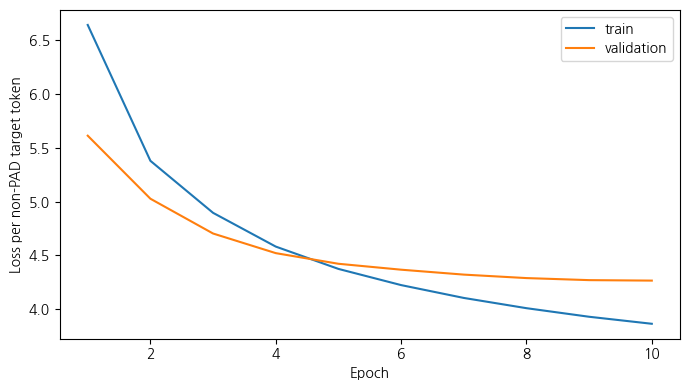

별도 test loss: 4.24


,korean,reference,prediction,eos
0,우비넨은 이후 경찰 특수 기동대가 학교 안으로 침투했을 때 건물 로비에서 자신의 머...,when the police s special swat unit entered th...,he was shot in the building when he was shot i...,True
1,리자 머피 레인포레스트 알리안스의 환경 보존 산림 프로그램 마케팅 담당자는 fsc의...,we applaud scholastic s progressive and bold c...,the environmental movement is the greatest cha...,True
2,그는 그날 다른 두 명도 죽인 것으로 여겨진다 .,he is also thought to have killed two people e...,he said that two other people were killed .,True
3,도시의 거리를 따라 운전을 하다 보면 음식점이 댈러스 산업의 상당한 부분을 차지하고...,drive down any downtown street and it s clear ...,the city s main street is a big part of the da...,True
4,만일 명이 선발되면 각각 만달러씩 나눠 지급받는다 .,"if only two ideas are chosen , each will recei...","if you get , , you know , you re getting a mil...",True


In [15]:
if not BEST_PATH.exists():
    raise FileNotFoundError("best.pt가 없습니다. 최소 1 epoch를 완료한 뒤 평가하세요.")
best_state = torch.load(BEST_PATH, map_location="cpu", weights_only=True)
if best_state["signature"] != TRAIN_SIGNATURE:
    raise ValueError("best.pt의 설정이 현재 설정과 다릅니다. 올바른 RUN_NAME과 설정을 복원하세요.")
if "transformer" in globals():
    del transformer
best_model = Transformer(**MODEL_CONFIG).to(device)
best_model.load_state_dict(best_state["model"])
best_model.eval()
best_epoch = best_state["epoch"]
best_val_loss = best_state["val_loss"]
del best_state
print(f"선택 모델: epoch {best_epoch}, validation loss {best_val_loss:.4f}")

latest = torch.load(LATEST_PATH, map_location="cpu", weights_only=True)
history = pd.DataFrame(latest["progress"]["history"])
del latest
if not history.empty:
    display(history)
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], history["train_loss"], label="train")
    plt.plot(history["epoch"], history["val_loss"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss per non-PAD target token")
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULT_DIR / "loss_curve.png", dpi=140)
    plt.show()

test_loss = evaluate_loss(best_model, dataset["test"])
print("별도 test loss:", round(test_loss, 4))
test_rows = []
for ko, en in dataset["test"]["pairs"][:TEST_EXAMPLES]:
    result = evaluate(ko, best_model)
    test_rows.append({"korean": ko, "reference": en, "prediction": result["text"],
                      "eos": result["ended_with_eos"]})
test_table = pd.DataFrame(test_rows)
display(test_table)
test_table.to_csv(RESULT_DIR / "test_translations.csv", index=False, encoding="utf-8-sig")

## 10. ★ 예문 4개·직접 입력한 문장 번역
아래 `MY_SENTENCES`에 문장을 추가할 수 있습니다. 과제 예문은 항상 별도로 출력·저장합니다.
**번역이 자연스러워 보여도 원문에 없는 정보가 붙었는지 확인**하세요. 예를 들어 '일곱 명이 사망했다'에 공격·지역·인물 정보를 임의로 추가했다면 오류입니다.

In [16]:
# ★ 이 목록에 직접 번역해 보고 싶은 한국어를 넣으세요.
MY_SENTENCES = ["나는 커피를 좋아한다."]

example_results, example_rows = [], []
for sentence in EXAMPLES:
    result = translate(sentence, best_model)
    example_results.append(result)
    example_rows.append({"korean": sentence, "prediction": result["text"],
                         "eos": result["ended_with_eos"], "meaning_review": "직접 평가"})
example_table = pd.DataFrame(example_rows)
display(example_table)
example_table.to_csv(RESULT_DIR / "rubric_examples.csv", index=False, encoding="utf-8-sig")
for sentence in MY_SENTENCES:
    translate(sentence, best_model)

한국어: 오바마는 대통령이다.
영어: obama is a president .
한국어: 시민들은 도시 속에 산다.
영어: the cities are in the town .
한국어: 커피는 필요 없다.
영어: coffee is not necessary .
한국어: 일곱 명의 사망자가 발생했다.
영어: the death toll was killed in the town of java .


,korean,prediction,eos,meaning_review
0,오바마는 대통령이다.,obama is a president .,True,직접 평가
1,시민들은 도시 속에 산다.,the cities are in the town .,True,직접 평가
2,커피는 필요 없다.,coffee is not necessary .,True,직접 평가
3,일곱 명의 사망자가 발생했다.,the death toll was killed in the town of java .,True,직접 평가


한국어: 나는 커피를 좋아한다.
영어: i love you .


## 11. Attention Map으로 결과 확인
**Cross-Attention:** 가로축은 한국어 Key, 세로축은 **그 행을 이용해 예측한 영어 토큰**입니다.
BOS 입력 행은 첫 영어 토큰을 예측하므로, BOS 라벨을 첫 예측 단어로 착각하지 않게 생성 시점마다 마지막 query 행을 따로 모았습니다.
색은 어디를 상대적으로 많이 참조했는지를 보여주며, 번역 정확성이나 인과관계를 증명하지 않습니다.

`ATTENTION_LAYER=-1`: 마지막 층. `ATTENTION_HEAD=None`: head 평균. 특정 head는 0~7로 바꿉니다.
평균은 서로 다른 head의 특징을 섞을 수 있습니다. 첫 단어가 반드시 흐릿하다거나 특정 층이 반드시 특정 역할을 한다고 단정하지 마세요.
`_`는 SentencePiece의 단어 경계 표식을 표시한 것이며 단어의 일부가 아닙니다.

**Decoder Self-Attention:** 두 축 모두 실제 디코더 **입력** 토큰입니다. 오른쪽 위가 0이면 미래 토큰이 가려진 것입니다.

예문 1: 오바마는 대통령이다. → obama is a president .


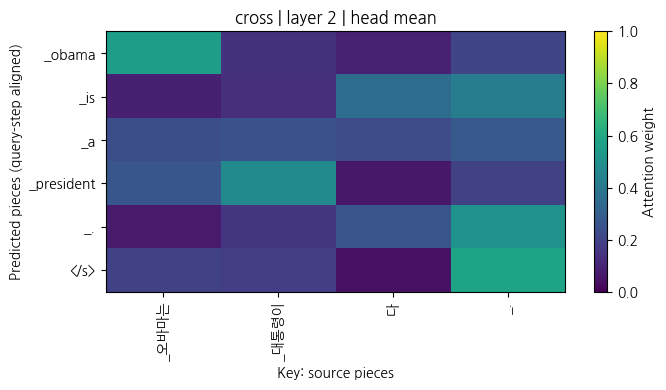

예문 2: 시민들은 도시 속에 산다. → the cities are in the town .


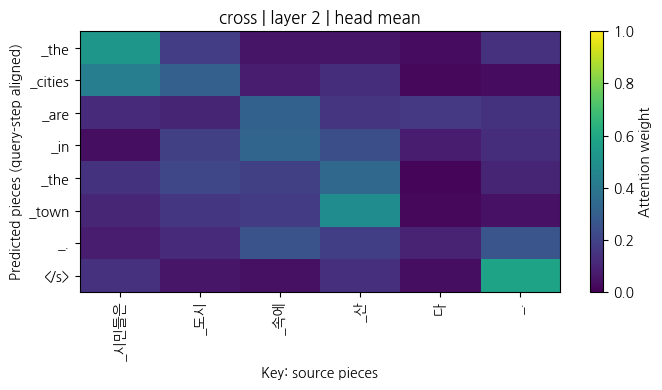

예문 3: 커피는 필요 없다. → coffee is not necessary .


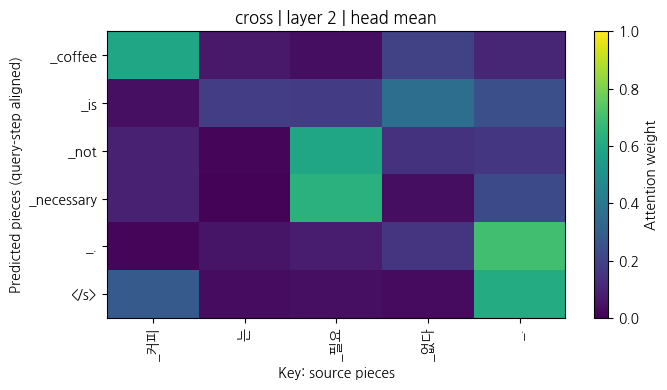

예문 4: 일곱 명의 사망자가 발생했다. → the death toll was killed in the town of java .


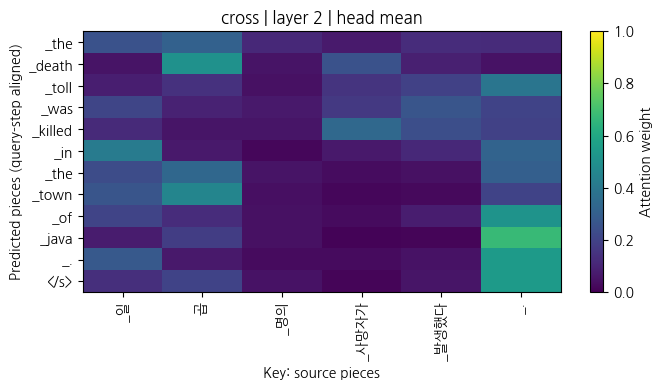

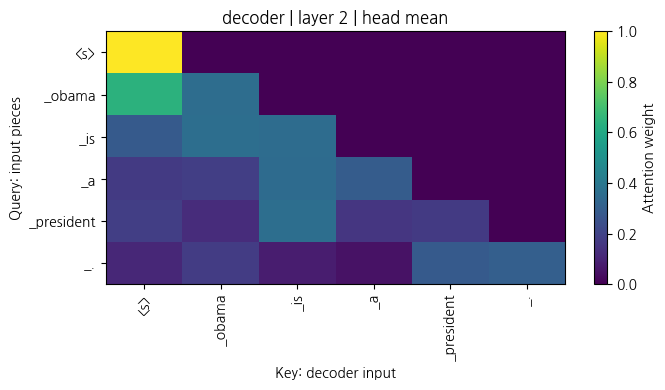

In [17]:
def plot_attention_map(result, kind="cross", layer=-1, head=None, filename=None):
    weights = result[kind][layer]  # [heads, query_length, key_length]
    if head is not None and not 0 <= head < weights.size(0):
        raise ValueError(f"head는 0~{weights.size(0) - 1} 또는 None이어야 합니다.")
    matrix = weights.mean(dim=0) if head is None else weights[head]
    if kind == "cross":
        x_labels, y_labels = result["src_labels"], result["output_labels"]
    elif kind == "encoder":
        x_labels = y_labels = result["src_labels"]
    else:
        x_labels = y_labels = result["input_labels"]
    assert tuple(matrix.shape) == (len(y_labels), len(x_labels)), "축 라벨과 어텐션 위치가 다릅니다."
    figure, ax = plt.subplots(figsize=(max(7, len(x_labels) * 0.4), max(4, len(y_labels) * 0.3)))
    image = ax.imshow(matrix.numpy(), aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(x_labels)), x_labels, rotation=90)
    ax.set_yticks(range(len(y_labels)), y_labels)
    selected_layer = layer if layer >= 0 else len(result[kind]) + layer
    ax.set_title(f"{kind} | layer {selected_layer + 1} | head {head if head is not None else 'mean'}")
    ax.set_xlabel("Key: source pieces" if kind != "decoder" else "Key: decoder input")
    ax.set_ylabel("Predicted pieces (query-step aligned)" if kind == "cross" else "Query: input pieces")
    figure.colorbar(image, ax=ax, label="Attention weight")
    figure.tight_layout()
    if filename:
        figure.savefig(RESULT_DIR / filename, dpi=140)
    plt.show()
    plt.close(figure)

for index, result in enumerate(example_results, start=1):
    print(f"예문 {index}:", EXAMPLES[index - 1], "→", result["text"])
    plot_attention_map(result, "cross", ATTENTION_LAYER, ATTENTION_HEAD, f"attention_example_{index}.png")

# 첫 예문의 디코더 미래 마스크도 확인합니다.
plot_attention_map(example_results[0], "decoder", ATTENTION_LAYER, ATTENTION_HEAD, "decoder_causal_mask.png")

## 12. 제출 요약·회고 작성
아래 셀은 실제 실행 수치와 번역을 요약 파일에 저장합니다. **의미 평가와 Attention 해석은 직접 작성**해야 합니다.
모델 출력이 만족스럽지 않다면 이를 숨기지 말고, 무엇이 틀렸고 어떤 설정으로 개선을 시도했는지 기록하세요.

| 예문 | 핵심 확인 내용 |
|---|---|
| 오바마는 대통령이다. | 인물·직책 보존, 불필요한 수식 추가 여부 |
| 시민들은 도시 속에 산다. | 시민·도시·거주 의미의 보존 |
| 커피는 필요 없다. | 커피·필요성의 **부정** 보존 |
| 일곱 명의 사망자가 발생했다. | **일곱 명**·사망 의미 보존, 공격 등 근거 없는 내용 추가 여부 |

학습 후 노트북의 실행 출력과 그림을 저장한 상태로 GitHub에 올려야 제출 자료가 됩니다.
Colab의 Drive 학습파일 저장과 GitHub의 노트북 출력 저장은 별개입니다.

In [18]:
summary_lines = [f"# 실험 요약: {RUN_NAME}", "",
                 f"- 선택 epoch: {best_epoch}", f"- Validation loss: {best_val_loss:.4f}",
                 f"- Test loss: {test_loss:.4f}", f"- 실행 장치: {device}",
                 "", "## 설정", "```json", json.dumps(TRAIN_SIGNATURE, ensure_ascii=False, indent=2),
                 "```", "", "## 전처리 통계", "```json",
                 json.dumps(data_meta["stats"], ensure_ascii=False, indent=2), "```", "", "## 예문 번역"]
for row in example_rows:
    summary_lines.extend([f"### {row['korean']}", row["prediction"],
                          f"EOS 도달: {row['eos']}", "의미 보존·누락·추가 평가: [직접 작성]", ""])
summary_lines.extend(["## Attention 해석", "관찰한 층/head와 대응 토큰: [직접 작성]",
                      "관찰만으로 확정할 수 없는 점: [직접 작성]", "", "## 회고",
                      "변경한 설정과 변경 이유: [직접 작성]", "좋아진 점과 남은 오류: [직접 작성]",
                      "다음에 한 가지 바꿔볼 설정: [직접 작성]"])
(RESULT_DIR / "submission_summary.md").write_text("\n".join(summary_lines), encoding="utf-8")
print("결과 저장 폴더:", RESULT_DIR)
print("코드 동작 검사와 의미 있는 번역의 달성은 별개입니다. 실제 출력·그림과 회고를 함께 제출하세요.")

결과 저장 폴더: /content/drive/MyDrive/Aiffel_EPA/transformer/runs/baseline_v1/results
코드 동작 검사와 의미 있는 번역의 달성은 별개입니다. 실제 출력·그림과 회고를 함께 제출하세요.


## 13. 다음 실험에서 무엇을 바꿀까?
| 상황 | 먼저 조절할 곳 | 주의 |
|---|---|---|
| 실행 흐름만 확인 | 새 이름 + `MAX_PAIRS=3000`, `EPOCHS=1` | 제출 성능의 근거로 사용하지 않기 |
| 학습을 더 진행 | 같은 이름 + `EPOCHS=15` | 기존 10회 완료 시 11~15회만 진행 |
| 메모리 부족 | 새 이름 + `BATCH_SIZE=16` | 같은 체크포인트의 배치 크기는 바꾸지 않기 |
| train loss만 내려감 | 새 이름 + `DROPOUT=0.3` | validation loss·번역을 함께 비교 |
| 작은 모델과 큰 모델 비교 | 새 이름 + `D_MODEL=512`, `D_FF=2048` | 메모리·계산량 증가, 나머지 설정 고정 |
| 작은 실행 확인에서 학습률이 너무 느리게 증가 | 새 이름 + `WARMUP_STEPS=100` | 정식 실험에서는 교재 기본 4000부터 비교 |
| 단어장 실험 | 새 이름 + 언어별 vocab 8000/20000 | 문장 분절·길이 필터 통과 수도 바뀜 |
| 이미 학습한 모델로 번역만 | 같은 설정 + `RUN_TRAINING=False` | 토크나이저·모델 설정은 그대로 유지 |

**한 번에 하나씩 변경**하고 실험 이름·validation loss·번역 오류를 비교하세요.
Noam 스케줄에서 `lr=1.0`은 최종 학습률이 아니라 기준 배율이므로 이를 일반 고정 학습률처럼 해석하지 않습니다.
`MAX_LEN=50`, `N_LAYERS=2`, 특수 토큰 ID는 과제 제출 시 유지하세요.

### 실행 검증 범위
CPU의 작은 **합성 문장 데이터**로 전체 셀 실행과 전처리·학습·저장/재개·평가·그림 흐름을 검사했습니다. 중간 배치에서 복원한 CPU 학습 결과가 중단 없이 학습한 결과와 정확히 일치하는지도 확인했습니다. 이는 번역 품질의 검증은 아닙니다.
실제 뉴스 데이터 전체 학습, Colab의 Drive 인증, CUDA 및 Apple MPS 실기 실행은 이 파일 제작 환경에서 수행하지 않았습니다.
새 커널에서 위에서부터 실행하고 6번의 장치·마스크 검사, 첫 epoch 저장, 재실행 시 재개 메시지를 확인하세요.

### 참고 자료
교재 두 파일의 모델 구성·과제 조건과 원본 노트북을 참고했습니다. 일반화 확인용 데이터 분리, 체크포인트 안전 검사, 실행 기록은 보완 기능입니다.
- [데이터 원본](https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1)
- [SentencePiece 공식 문서](https://github.com/google/sentencepiece)
- [PyTorch MPS](https://docs.pytorch.org/docs/stable/notes/mps.html)
- [PyTorch 저장·복원](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)
- [torch.load의 map_location·weights_only](https://docs.pytorch.org/docs/stable/generated/torch.load.html)
- [Colab Drive I/O 주의사항](https://research.google.com/colaboratory/faq.html)
- [Google Drive for desktop 동기화](https://support.google.com/drive/answer/13401938)